# Lightweight Bounded Model Checker (BMC)
**CS 6315 – Automated Verification**

Le’Shawn Sears  
Final Project Report

In [1]:
import sys, os
sys.path.append(".")      # so "bmc", "model", etc. can be imported

# Core BMC components
from bmc.model import TransitionSystem
from bmc.solver import BMCSolver
from bmc.bmc import run_bmc, extract_trace

# Visualization + utilities
import json
import matplotlib.pyplot as plt
import networkx as nx

## Introduction

Bounded Model Checking (BMC) is a lightweight verification approach that examines system behavior within a fixed number of steps. Rather than requiring exhaustive traversal of the entire state space which often becomes intractable, BMC restricts analysis to execution paths of length k. This bounded exploration is particularly powerful for discovering shallow bugs, unreachable states, or property violations that occur early in execution. By framing the problem as a satisfiability question, BMC asks: “Is there a path of length ≤ k that violates the desired property?”

To answer this question, BMC relies on symbolic encoding using the Z3 SMT solver. Each timestep, transition, and property constraint is represented as a logical formula, allowing Z3 to efficiently reason about all possible executions simultaneously. When a property is violated, the solver returns a concrete counterexample trace demonstrating how the violation occurs. The checker implemented in this project supports both reachability analysis and safety checking, focusing on small finite-state transition systems for clarity and interpretability. This scope allows the project to highlight the essential ideas of symbolic verification while maintaining a fully functional, extensible prototype tool.

### 1.1 Background on Symbolic Encoding

BMC relies on symbolic encoding, where system states, transitions, and properties are represented as logical constraints instead of enumerated explicitly. Using an SMT solver like Z3, the unrolled transition system is converted into a formula whose satisfiability indicates whether a counterexample of length ≤ k exists. If SAT, the solver produces a concrete trace. Symbolic encoding allows compact representation and efficient reasoning, enabling BMC to analyze many possible executions simultaneously.

### 1.2 Moivation

Full state-space exploration in model checking can become infeasible due to exponential growth in system behaviors. Bounded Model Checking (BMC) provides a practical alternative by examining only executions up to a finite depth k. This allows detection of early property violations without requiring exhaustive search. The goal of this project is to build a lightweight BMC tool that verifies reachability and safety properties for small finite-state transition systems, demonstrating how bounded reasoning and solver-based analysis can identify correctness issues efficiently.

### 1.3 Project Architecture Overview

- Describe modules
    - `model.py`: Transistion system
    - `solver.py`: BMCSolver (Z3 wrapper)
    - `bmc.py`: run_bmc + encoding
    - `main.py`: CLI

Diagram (ASCII or NetworkX):
JSON Model → TransitionSystem → BMC Encoding → Z3 → SAT/UNSAT → Trace


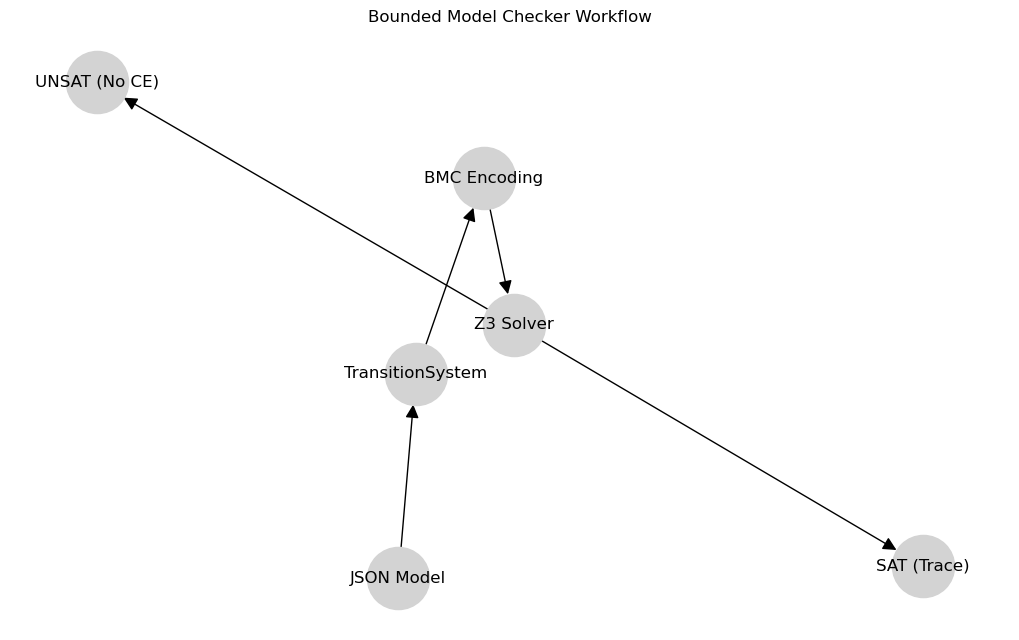

In [2]:
G = nx.DiGraph()

nodes = [
    "JSON Model",
    "TransitionSystem",
    "BMC Encoding",
    "Z3 Solver",
    "SAT (Trace)",
    "UNSAT (No CE)"
]

edges = [
    ("JSON Model", "TransitionSystem"),
    ("TransitionSystem", "BMC Encoding"),
    ("BMC Encoding", "Z3 Solver"),
    ("Z3 Solver", "SAT (Trace)"),
    ("Z3 Solver", "UNSAT (No CE)")
]

G.add_nodes_from(nodes)
G.add_edges_from(edges)

plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)
nx.draw(G, pos, with_labels=True, node_size=2000, node_color="lightgray", arrowsize=20)
plt.title("Bounded Model Checker Workflow")
plt.show()


## 2. Setup (Environment + Models)


Subsections:
- 2.1 Loading Transition System models
- 2.2 Visualizing state graphs


**JSON model format explanation:**

Each transition system used by the bounded model checker is defined in a simple JSON format.

- `name` - identifier for the model
- `states` - list of all states in the sytem
- `init` - the initial state
- `transitions` - mapping from each state to the list of its outgoing successors

Example JSON:

```JSON
{
  "name": "ToggleSystem",
  "states": ["s0", "s1"],
  "init": "s0",
  "transitions": {
    "s0": ["s1"],
    "s1": ["s0"]
  }
}

```

This describes a simple two-state toggle system where `s0` transitions to `s1`, and `s1` returns to `s0`.


**Mapping to the TransitionSystem object**
- `states` → stored as a list of state names
- `init` → the designated initial state
- `transitions` → a dictionary representing the graph structure

This structure keeps the representation minimal while capturing all information needed for BMC unrolling, symbolic encoding, and trace extraction.

### 2.1 Initialization

In [3]:
def load_model(path):
    return TransitionSystem.from_json(path)

toggle = load_model("examples/toggle.json")
traffic = load_model("examples/trafficlight.json")
unreachable = load_model("examples/unreachable.json")

print(toggle)
print(unreachable)
print(traffic)


TransitionSystem(name='ToggleSystem', states=['s0', 's1'], init='s0', transitions={'s0': ['s1'], 's1': ['s0']}, variables={})
TransitionSystem(name='UnreachableExample', states=['s0', 's1', 'error'], init='s0', transitions={'s0': ['s1'], 's1': []}, variables={})
TransitionSystem(name='TrafficLightSystem', states=['Green', 'Yellow', 'Red', 'Error'], init='Green', transitions={'Green': ['Yellow'], 'Yellow': ['Red'], 'Red': ['Green', 'Error'], 'Error': []}, variables={})


### 2.2 Visualizing the Transistion System

In [4]:
def visualize_ts(ts):
    G = nx.DiGraph()
    for s, nxt in ts.transitions.items():
        for t in nxt:
            G.add_edge(s, t)
    plt.figure(figsize=(6,6))
    nx.draw_networkx(G, with_labels=True, node_color='lightblue')
    plt.axis('off')
    plt.show()


Toggle State Example


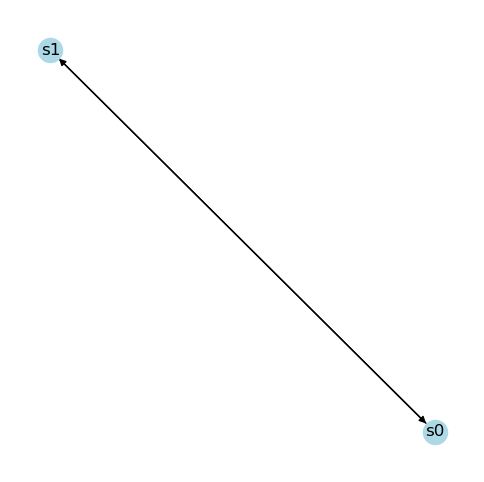

Unreachable State Example


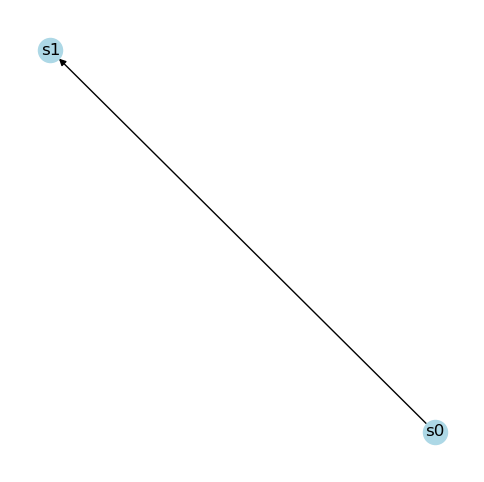

Traffic Light Example


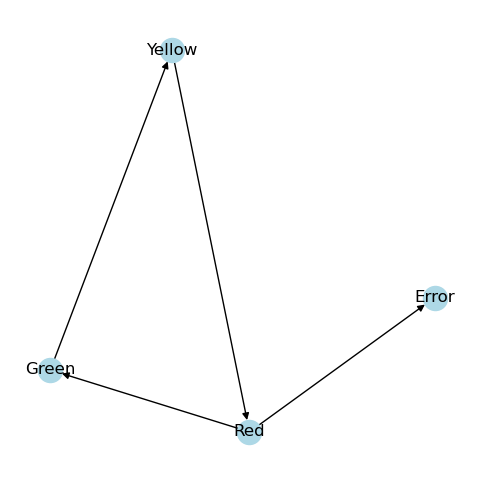

In [5]:
print("Toggle State Example")
visualize_ts(toggle)
print("Unreachable State Example")
visualize_ts(unreachable)
print("Traffic Light Example")
visualize_ts(traffic)

## 3. Running Bounded Model Checking: Reachability

- Reachability means ∃ path to state p within bound k
- SAT = reachable, UNSAT = not reachable

### 3.1 Reachability Checking

Reachability checking asks whether a chosen target state can be reached within a bounded number of steps.
The bounded model checker encodes the question:

“Does there exist a timestep t ≤ k where the target state is active?”

If the solver returns SAT, a valid execution path exists and the trace is shown.
If UNSAT, no such path exists within the given depth.
The following examples demonstrate reachability on the toggle and unreachable systems.


In [6]:
# --- Reachability Examples ---

# Toggle: target s1
sat, trace = run_bmc(toggle, bound=5, target_state="s1", safety=False)
print("Toggle reachability(s1):", sat, trace)

# Unreachable: target s1
sat, trace = run_bmc(traffic, bound=5, target_state="s0", safety=False)
print("Unreachable reachability(s0):", sat, trace)


Toggle reachability(s1): True ['s0', 's1', 's0', 's1', 's0', 's1']
Unreachable reachability(s0): False None


### 3.2 Safety Checking

Safety checking verifies whether a “bad” state (such as Error) can be reached within the given bound.
If the solver reports SAT, a violation exists and the trace shows how the system reaches that bad state.
If UNSAT, no safety violation is possible within the chosen bound.

In [ ]:

# --- Safety Example (Traffic Light) ---
sat, trace = run_bmc(traffic, bound=5, target_state="Error", safety=True)

if sat:
    print("Safety violated: Error reachable. Counterexample:", trace)
else:
    print("Safety holds up to bound: Error unreachable.")


Safety violated: Error reachable. Counterexample: ['Green', 'Yellow', 'Red', 'Error', 'Error', 'Error']


### 3.3 Edge Cases

This section groups several transition systems that illustrate important boundary conditions for bounded model checking.
Each example highlights a different structural challenge: nondeterminism, deep chains, dead ends, and cycles with embedded error states.

Testing edge cases helps confirm that the BMC encoding correctly handles all forms of state-space structure.

---
**NondetExplosion (State Explosion Behavior)**

A highly nondeterministic root state transitions to eight different successors.
The solver must choose one consistent path among many possibilities.
Reachability queries will always find a path to any of the branch states within depth 1.

---
**DeepChain (Long Linear Error Path)**

Represents a single linear chain of states that reaches `error` only at depth 6.
This tests bound sensitivity:

Small bounds incorrectly show safety (UNSAT)

A bound ≥ 6 exposes the violation

---
**DeadEndExample (Terminal States and Goal Branches)**

This model contains both a dead-end (`dead`) and a self-looping goal state (`goal`).
The checker must correctly handle states with zero outgoing transitions and states with infinite continuation.

---
**CycleWithError (Cyclic Behavior With Immediate Violation)**

A cycle exists among `A → B → C → A`, but `A` also nondeterministically transitions to `Error`.
A safety query must detect that the violation is reachable at depth 1.

In [14]:
# Load all edge-case models properly
edge_models = {
    "NondetExplosion": "examples/nondeterministic.json",
    "DeepChain":       "examples/deepchain.json",
    "DeadEndExample":  "examples/deadend.json",
    "CycleWithError":  "examples/cyclicerror.json"
}

# Convert JSON files → TransitionSystem objects
edge_cases = []
for name, path in edge_models.items():
    ts_obj = TransitionSystem.from_json(path)
    edge_cases.append((name, ts_obj))

print("=== Edge Case Testing ===\n")

for name, model in edge_cases:
    print(f"--- {name} ---")

    # Decide reachability target:
    # If the model has an explicit error state, test reachability of it.
    # Otherwise, target the last-listed state in the model.
    if "error" in model.states:
        target = "error"
    elif "Error" in model.states:
        target = "Error"
    else:
        target = model.states[-1]

    # Reachability query
    sat_r, trace_r = run_bmc(model, bound=6, target_state=target, safety=False)
    print(f"Reachability({target}): SAT={sat_r}, Trace={trace_r}")

    # Safety: is 'Error' reachable?
    # If model has no Error/error state, safety holds trivially.
    if ("Error" in model.states) or ("error" in model.states):
        bad = "Error" if "Error" in model.states else "error"
        sat_s, trace_s = run_bmc(model, bound=6, target_state=bad, safety=True)

        if sat_s:
            print(f"Safety violated: '{bad}' reachable. Counterexample: {trace_s}")
        else:
            print(f"Safety holds: '{bad}' unreachable within bound.")
    else:
        print("(Safety) No error state present → trivially safe.")

    print()


=== Edge Case Testing ===

--- NondetExplosion ---
Reachability(h): SAT=True, Trace=['s0', 'c', 's0', 'e', 's0', 'h', 's0']
(Safety) No error state present → trivially safe.

--- DeepChain ---
Reachability(error): SAT=True, Trace=['s0', 's1', 's2', 's3', 's4', 's5', 'error']
Safety violated: 'error' reachable. Counterexample: ['s0', 's1', 's2', 's3', 's4', 's5', 'error']

--- DeadEndExample ---
Reachability(goal): SAT=True, Trace=['start', 'branch1', 'goal', 'goal', 'goal', 'goal', 'goal']
(Safety) No error state present → trivially safe.

--- CycleWithError ---
Reachability(Error): SAT=True, Trace=['A', 'B', 'C', 'A', 'Error', 'Error', 'Error']
Safety violated: 'Error' reachable. Counterexample: ['A', 'B', 'C', 'A', 'Error', 'Error', 'Error']



## 4. Bounded Model Checker (BMC) Review

This section reviews the structure and behavior of the bounded model checker.  
Given a transition system and a bound *k*, the BMC unrolls the system for *k* steps and asks Z3 whether a property is violated (safety) or satisfied (reachability).

---

### 4.1 Boolean State Variables
For every state `s` and every timestep `t = 0…k`, the BMC creates a Boolean variable:

```
s_t  ≡  "the system is in state s at time t"
```

These variables represent all possible executions up to depth *k*.

---

### 4.2 Initial State Constraint
At `t = 0`, exactly one state must be true:

```
init_0 = True
all other s_0 = False
```

This ensures all execution traces begin at the correct initial configuration.

---

### 4.3 Transition Relation
For each step `t → t+1`, if the system is in state `s_t`, it must move to one of its successors:

```
s_t → (succ1_(t+1) ∨ succ2_(t+1) ∨ …)
```

If a state has **no outgoing transitions**, the model uses a stuttering rule:

```
s_t → s_(t+1)
```

This prevents dead-end states from violating the consistency constraints.

---

### 4.4 Exclusivity Constraint
At each timestep, exactly one state must be active:

1. **At least one** state is true  
2. **At most one** state is true  

This enforces standard finite-state–machine semantics.

---

### 4.5 Property Encoding

### Reachability
“Is the target state reachable within 0…k?”

```
goal = OR( target_t for t = 0..k )
```

If SAT → the trace is a *witness path* to the target.

### Safety Violation
“Can a bad state (`Error`/`error`) be reached within 0…k?”

```
goal = OR( bad_state_t for t = 0..k )
```

If SAT → a *counterexample trace* shows how safety is violated.  
If UNSAT → safety holds up to bound *k*.

---

### 4.6 Edge Case Behavior
The BMC correctly handles:
- **Dead ends** (forced stuttering)
- **Self-loops and absorbing states**
- **Nondeterministic branching**
- **Deep deterministic chains**
- **Cyclic systems**, including cycles that eventually reach error

These tests validate the correctness of the transition and exclusivity encodings.

---

### 4.7 Scalability Notes (Brief)
- Encoding size grows **linearly** with the bound (*O(|States| × k)*).
- Solver difficulty grows with the **branching factor**, not with depth alone.
- Deterministic chains solve quickly; nondeterministic models slow down due to path explosion.


## 5. Conclusion

### 5.1 Summary of the System

This project implemented a **lightweight bounded model checker (BMC)** capable of verifying finite-state transition systems using SAT/SMT solving.  
The tool supports:

- Boolean time-unrolled encodings  
- Exact initial state constraints  
- Deterministic and nondeterministic transitions  
- Dead-end handling through stuttering semantics  
- Exclusivity (exactly one active state at each timestep)  
- Two property-checking modes:
  - **Reachability**: Can a target state be reached?
  - **Safety violation search**: Can a bad state (`Error`/`error`) be reached?

Across all demonstrations, the BMC successfully constructed traces showing how Z3 satisfies or disproves each query.

---

### 5.2 Strengths and Limitations

### **Strengths**
- Clean, minimal SAT-based encoding using only Boolean variables.
- Compatible with any JSON-specified finite transition system.
- Provides **concrete execution traces**, improving interpretability.
- Correct handling of:
  - nondeterministic branching,
  - deep linear chains,
  - cycles,
  - dead-ends,
  - and error-propagation systems.

### **Limitations**
- **Bounded completeness**:  
  Only behaviors up to depth *k* are analyzed; deeper violations may be missed.
- No built-in detection of:
  - fairness constraints  
  - liveness violations  
  - loop-based counterexamples (e.g., Büchi automata)
- State explosion occurs when:
  - branching factor is high,  
  - the depth bound increases,  
  producing exponential SAT encodings.

---

### 5.3 Future Improvements

Several enhancements could significantly extend the model checker's expressiveness and performance:

### **LTL Support**
Add operators:
- ◇ (eventually)  
- □ (always)  
- U (until)  
This requires loop-finding encodings and additional constraint layers.

### **General Liveness Checking**
Detect infinite behaviors violating liveness by:
- adding loop constraints,
- searching for repeated states,
- integrating Büchi automata construction.

### **Bit-Vector Encoding**
Replace purely Boolean states with:
- bit-vectors for numerical state variables,
- arithmetic transitions,
- counters or bounded data paths.

This allows richer hardware-style models and algorithms over bounded integers.

### **Model Composition**
Support parallel composition of systems:
- synchronous product,
- interleaving semantics,
- shared or independent variable sets.

This enables checking networks of interacting processes.

---

**Overall**, the project demonstrates a fully functioning bounded model checker with clear semantics, correct SAT encodings, and strong extensibility potential. It provides a solid foundation for more advanced symbolic verification tools.
